In [6]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Add project root to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from scripts.preprocessing import AutomatedPreprocessor

# Here we import and split the data
df = pd.read_csv("../data/mock/new/data.csv")

TARGET_COLUMN = "rating"
columns_to_ignore = [TARGET_COLUMN, "timePeriod", "session_id", "sent_at", "date", "Date", "id"]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Val Shape: {X_val_processed.shape}")
print(f"Processed Test Shape: {X_test_processed.shape}")

Processed Train Shape: (1704, 9)
Processed Val Shape: (427, 9)
Processed Test Shape: (533, 9)


In [7]:
# Random Forest Classification

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

y_train_pred = best_model.predict(X_train_processed)
y_val_pred = best_model.predict(X_val_processed)
y_test_pred = best_model.predict(X_test_processed)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nRandom Forest Results:")
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Best Parameters: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Random Forest Results:
Train Accuracy: 83.51%
Validation Accuracy: 82.90%
Test Accuracy: 80.11%

Validation Classification Report:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.82      0.93      0.87       227
           4       0.84      0.76      0.80       188
           5       0.00      0.00      0.00        11

    accuracy                           0.83       427
   macro avg       0.42      0.42      0.42       427
weighted avg       0.81      0.83      0.82       427


Test Classification Report:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         2
           3       0.78      0.93      0.85       283
           4       0.84      0.69      0.76       235
           5       0.00      0.00      0.00        13

    acc

C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas


--- Train Metrics ---
Accuracy:  0.8357
Precision (weighted): 0.8152
Recall (weighted):    0.8357
F1 Score (weighted):  0.8216

--- Test/Validation Metrics ---
Accuracy:  0.8290
Precision (weighted): 0.8068
Recall (weighted):    0.8290
F1 Score (weighted):  0.8152


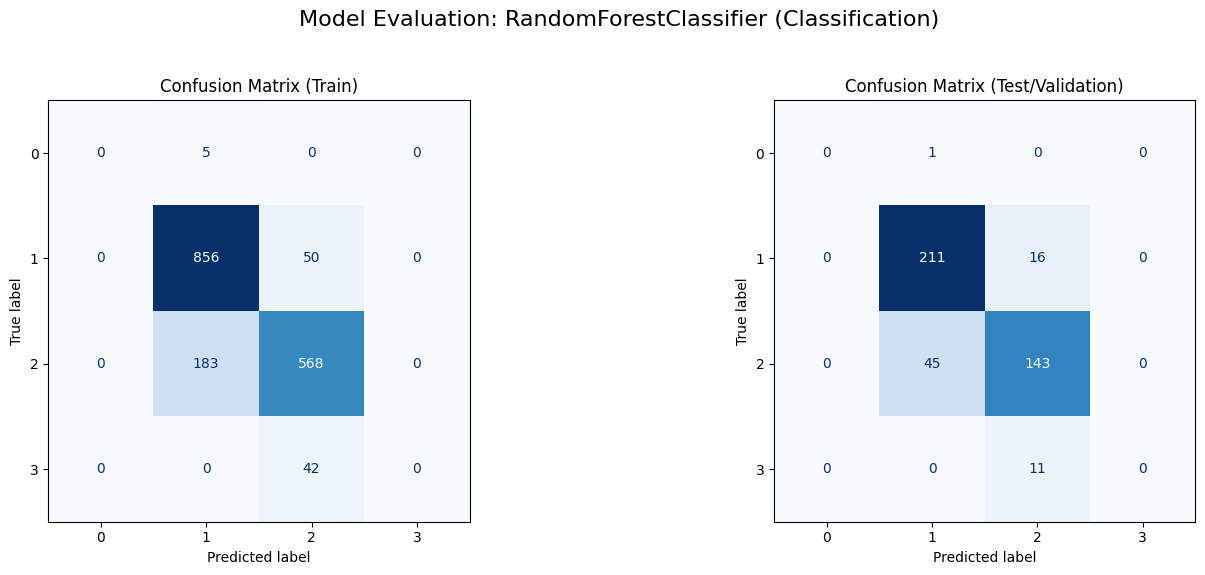

In [11]:
import importlib
import scripts.evaluation_metrics
importlib.reload(scripts.evaluation_metrics)
from scripts.evaluation_metrics import evaluate_model
best_model = RandomForestClassifier(class_weight= None, max_depth= 5, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 200)
best_model.fit(X_train_processed, y_train)


evaluate_model(best_model, X_train_processed, X_val_processed, y_train, y_val, True);
